# 03 — Analyse exploratoire des données (EDA)

## Objectif

Comprendre ce qui fait le succès d'un film à travers l'analyse de **2 976 films sortis entre 1980 et 2024**.

Les questions auxquelles on répond :

1. **Qui sont nos films ?** — distribution des budgets, recettes, durées, notes
2. **Comment évoluent les budgets et recettes au fil du temps ?**
3. **Quels genres dominent et lesquels sont les plus rentables ?**
4. **Y a-t-il une saisonnalité des sorties (les blockbusters d'été, les Oscars en fin d'année) ?**
5. **Les franchises sont-elles vraiment plus rentables que les films originaux ?**
6. **Quels réalisateurs ont le meilleur palmarès ?**
7. **Quelles variables prédisent le mieux le succès ?**

Ce notebook prépare le terrain pour la modélisation ML (notebook 04).

## 1. Imports et chargement

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

# Style des graphiques
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Chargement du dataset enrichi
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'movies_features.csv')
df['release_date'] = pd.to_datetime(df['release_date'])

# Re-parsing des colonnes liste
for col in ['genres', 'production_companies', 'cast_top5', 'cast_top5_popularity']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(f'Dataset chargé : {df.shape[0]} films, {df.shape[1]} colonnes')
print(f'Période : {df["release_year"].min()} - {df["release_year"].max()}')

Dataset chargé : 2976 films, 56 colonnes
Période : 1980 - 2024


## 2. Statistiques descriptives — qui sont nos films ?

In [2]:
stats_cols = ['budget', 'revenue', 'roi', 'runtime', 'vote_average', 'vote_count', 'popularity']
df[stats_cols].describe().round(2)

,budget,revenue,roi,runtime,vote_average,vote_count,popularity
count,2.976000e+03,2.976000e+03,2976.00,2976.00,2976.00,2976.00,2976.00
mean,5.371812e+07,1.823668e+08,9.90,113.65,6.80,4851.09,7.11
std,5.593870e+07,2.486338e+08,248.42,20.70,0.72,4953.36,7.83
min,7.000000e+03,7.000000e+00,-1.00,56.00,3.87,52.00,1.26
25%,1.500000e+07,3.726295e+07,0.51,98.75,6.32,1736.50,3.96
50%,3.400000e+07,1.005735e+08,1.88,110.00,6.81,3264.50,5.24
75%,7.500000e+07,2.199303e+08,4.23,125.00,7.31,6160.25,7.74
max,4.899000e+08,2.923706e+09,12889.39,229.00,8.72,39613.00,297.04


### 2.1 Distribution des budgets et recettes

On utilise une échelle logarithmique car les budgets/recettes varient sur plusieurs ordres de grandeur.

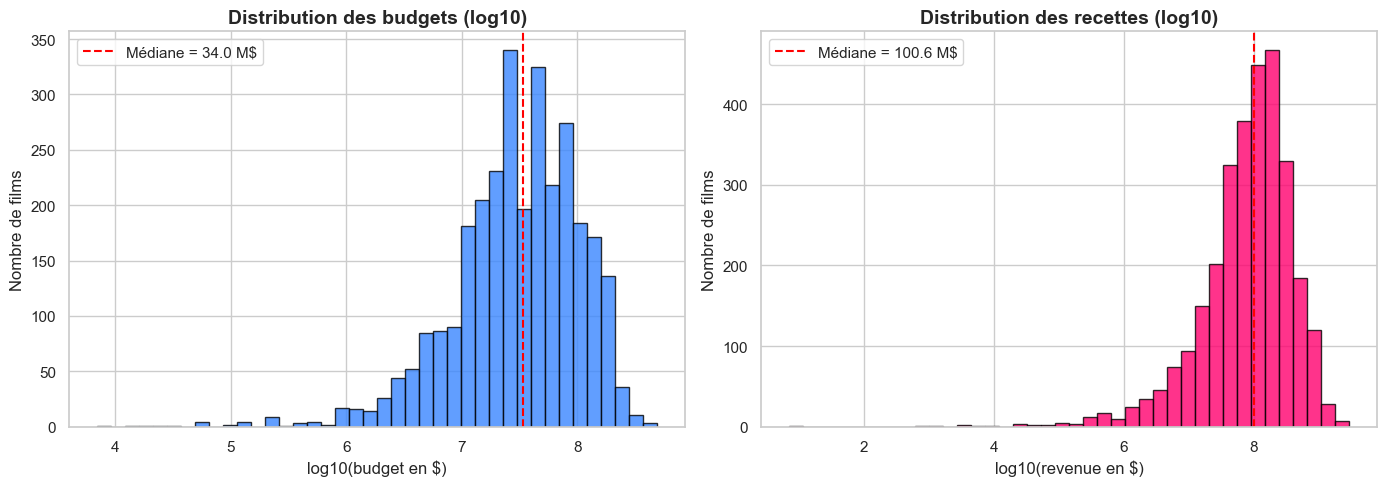

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log10(df['budget']), bins=40, color='#3a86ff', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution des budgets (log10)')
axes[0].set_xlabel('log10(budget en $)')
axes[0].set_ylabel('Nombre de films')
axes[0].axvline(np.log10(df['budget'].median()), color='red', linestyle='--', label=f"Médiane = {df['budget'].median()/1e6:.1f} M$")
axes[0].legend()

axes[1].hist(np.log10(df['revenue']), bins=40, color='#ff006e', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution des recettes (log10)')
axes[1].set_xlabel('log10(revenue en $)')
axes[1].set_ylabel('Nombre de films')
axes[1].axvline(np.log10(df['revenue'].median()), color='red', linestyle='--', label=f"Médiane = {df['revenue'].median()/1e6:.1f} M$")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.2 Distribution des notes et de la durée

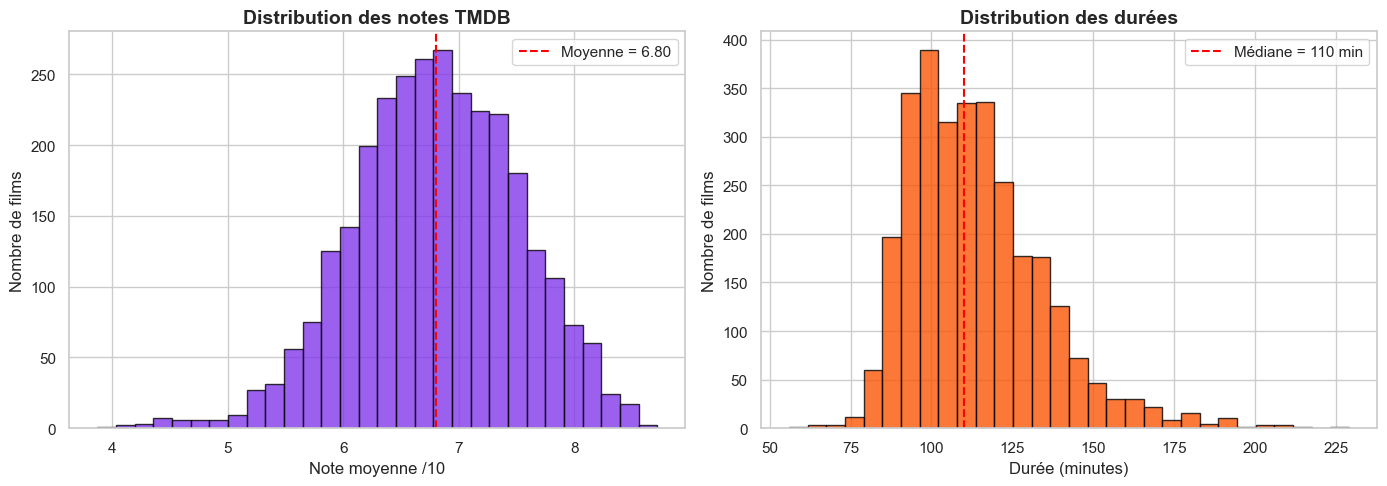

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['vote_average'], bins=30, color='#8338ec', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution des notes TMDB')
axes[0].set_xlabel('Note moyenne /10')
axes[0].set_ylabel('Nombre de films')
axes[0].axvline(df['vote_average'].mean(), color='red', linestyle='--', label=f"Moyenne = {df['vote_average'].mean():.2f}")
axes[0].legend()

axes[1].hist(df['runtime'], bins=30, color='#fb5607', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution des durées')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('Nombre de films')
axes[1].axvline(df['runtime'].median(), color='red', linestyle='--', label=f"Médiane = {df['runtime'].median():.0f} min")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Évolution temporelle — le cinéma au fil des décennies

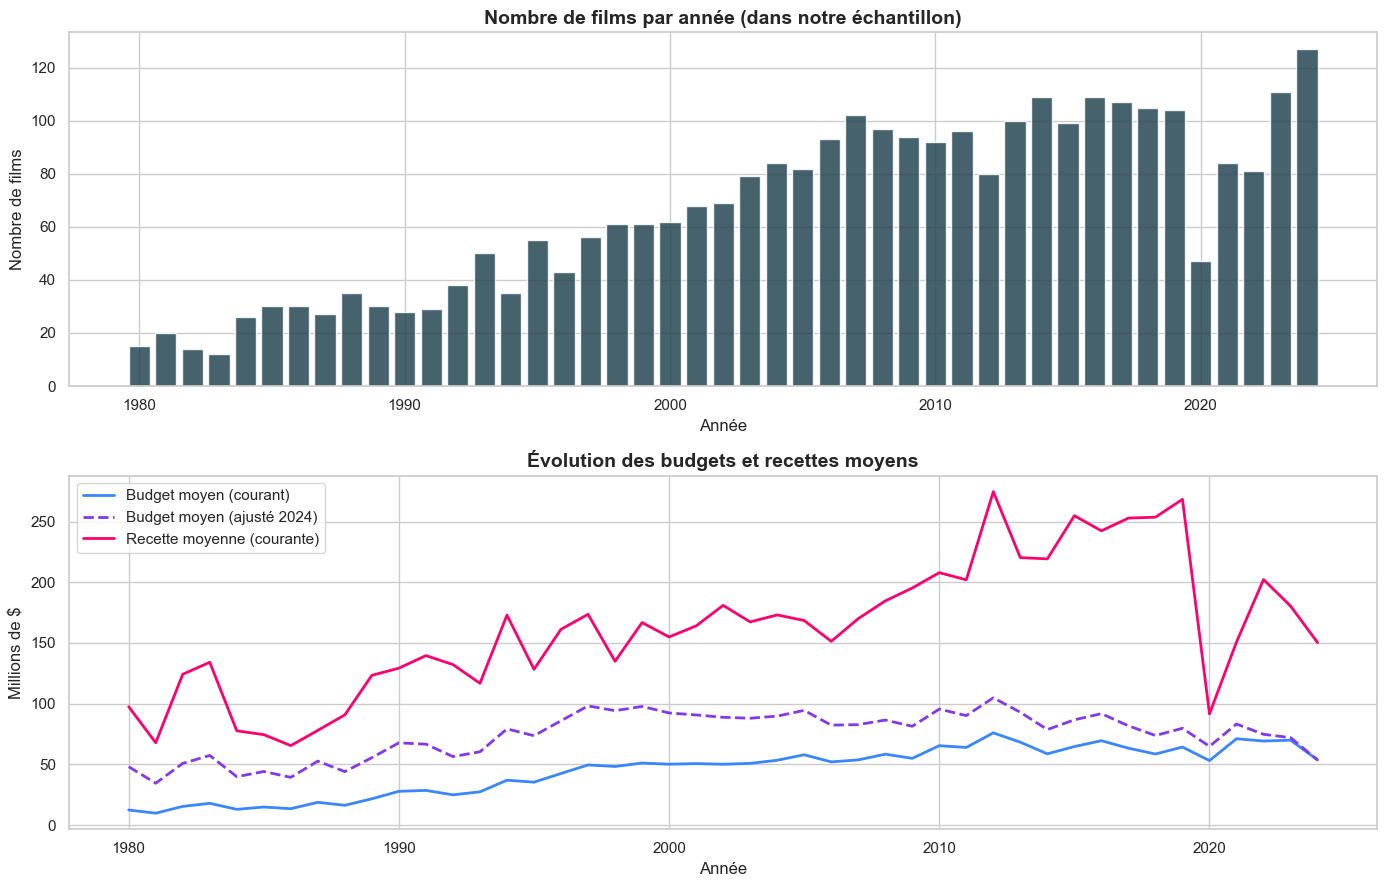

In [5]:
# Films par année (volume)
films_per_year = df.groupby('release_year').size()

# Budget et recettes moyens par année (en dollars courants ET en dollars 2024)
yearly = df.groupby('release_year').agg(
    budget_avg=('budget', 'mean'),
    budget_2024_avg=('budget_2024', 'mean'),
    revenue_avg=('revenue', 'mean'),
    revenue_2024_avg=('revenue_2024', 'mean'),
    n_films=('id', 'count'),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Volume de films
axes[0].bar(films_per_year.index, films_per_year.values, color='#264653', alpha=0.85)
axes[0].set_title('Nombre de films par année (dans notre échantillon)')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de films')

# Budget moyen courant vs ajusté inflation
axes[1].plot(yearly.index, yearly['budget_avg']/1e6, label='Budget moyen (courant)', color='#3a86ff', linewidth=2)
axes[1].plot(yearly.index, yearly['budget_2024_avg']/1e6, label='Budget moyen (ajusté 2024)', color='#8338ec', linewidth=2, linestyle='--')
axes[1].plot(yearly.index, yearly['revenue_avg']/1e6, label='Recette moyenne (courante)', color='#ff006e', linewidth=2)
axes[1].set_title('Évolution des budgets et recettes moyens')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Millions de $')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations** :
- Le **nombre de films** augmente fortement à partir des années 2000, puis chute en 2020 (COVID)
- Les **budgets explosent** depuis 2000 (effet inflation + concentration sur les blockbusters)
- En dollars constants 2024, l'augmentation reste forte mais plus modérée

## 4. Corrélations entre variables numériques

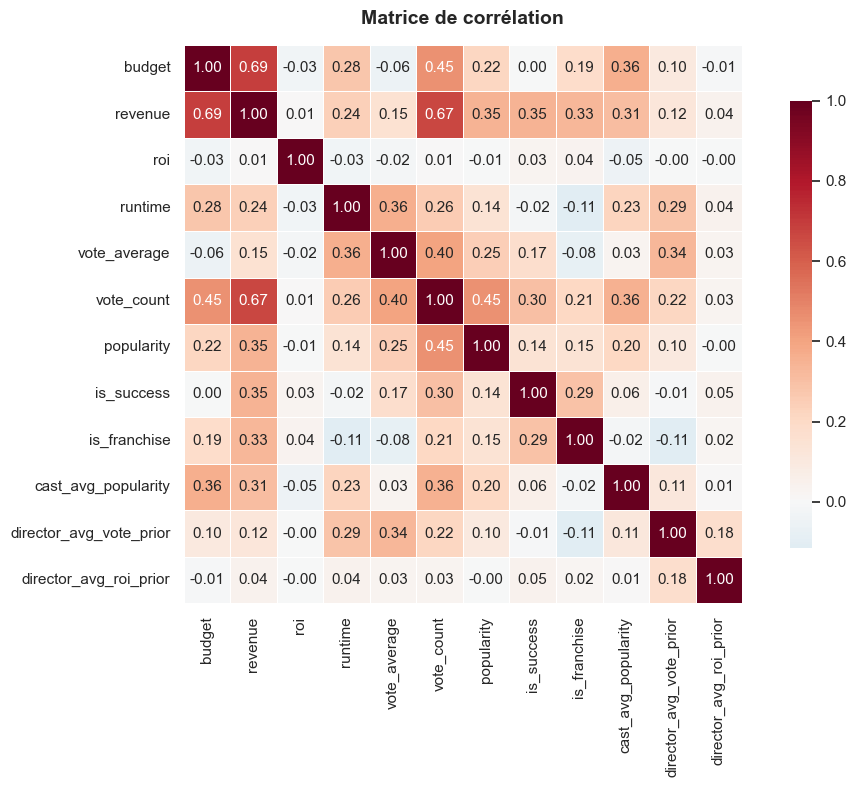

In [6]:
corr_cols = ['budget', 'revenue', 'roi', 'runtime', 'vote_average', 'vote_count',
             'popularity', 'is_success', 'is_franchise', 'cast_avg_popularity',
             'director_avg_vote_prior', 'director_avg_roi_prior']

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Lectures clés** :
- `budget` et `revenue` sont très corrélés (~0.7-0.8) → les gros budgets génèrent souvent de grosses recettes
- `vote_count` et `popularity` sont fortement liés (sens commun)
- `is_success` corrèle modérément avec la popularité et le casting
- Le ROI est **mal corrélé** avec le budget seul → le succès financier ne s'achète pas linéairement

## 5. Budget vs Recettes — l'analyse incontournable

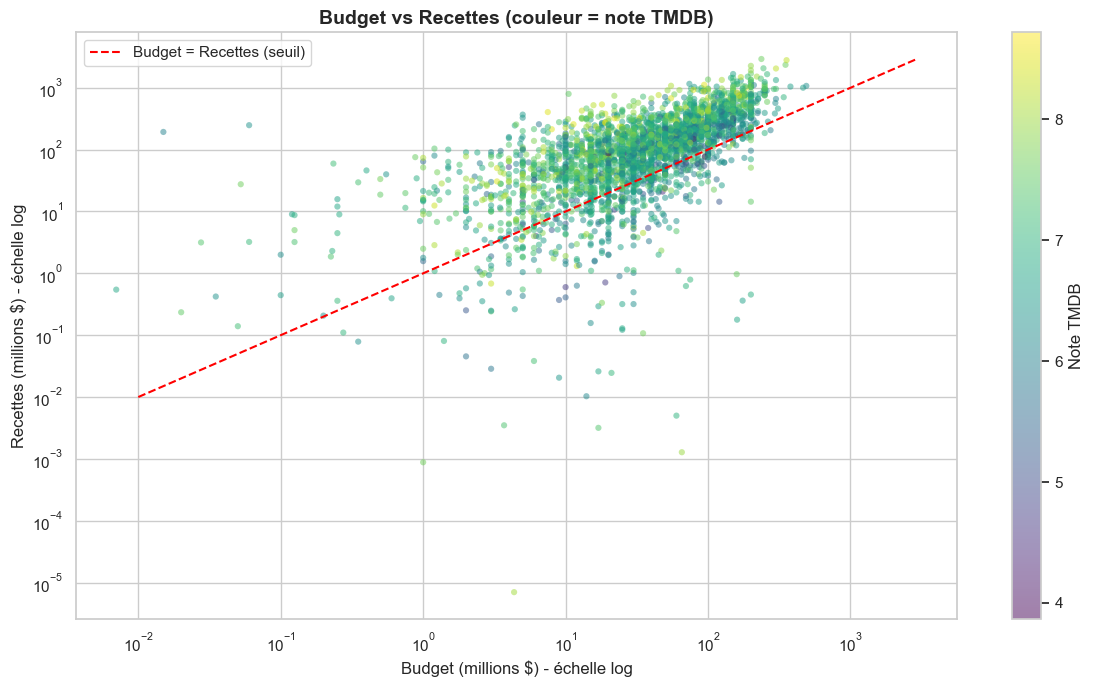

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(df['budget']/1e6, df['revenue']/1e6,
                     c=df['vote_average'], cmap='viridis',
                     alpha=0.5, s=20, edgecolor='none')

# Ligne y=x (budget = revenue, seuil de rentabilité simpliste)
lims = [0.01, max(df['budget'].max(), df['revenue'].max())/1e6]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Budget = Recettes (seuil)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Budget (millions $) - échelle log')
ax.set_ylabel('Recettes (millions $) - échelle log')
ax.set_title('Budget vs Recettes (couleur = note TMDB)')
plt.colorbar(scatter, label='Note TMDB')
ax.legend()
plt.tight_layout()
plt.show()

**Observations** :
- La majorité des films sont **au-dessus** de la ligne (rentables)
- Les films avec **petit budget** ont une grande variance de résultat (énormes hits ou flops)
- Les **gros budgets** sont en général rentables mais le ROI relatif est plus faible

## 6. Analyse par genre

In [8]:
# On 'explode' les genres (un film par genre)
df_genres = df.explode('genres').rename(columns={'genres': 'genre'})

genre_stats = df_genres.groupby('genre').agg(
    n_films=('id', 'count'),
    budget_mean=('budget', 'mean'),
    revenue_mean=('revenue', 'mean'),
    roi_median=('roi', 'median'),
    success_rate=('is_success', 'mean'),
    vote_avg=('vote_average', 'mean'),
).sort_values('n_films', ascending=False)

genre_stats.round(2)

,n_films,budget_mean,revenue_mean,roi_median,success_rate,vote_avg
genre,,,,,,
Drama,1112,37295211.31,1.228381e+08,1.70,0.62,7.11
Action,1084,75234090.29,2.305387e+08,1.52,0.61,6.65
Comedy,917,50087804.71,1.838743e+08,2.31,0.73,6.66
Thriller,871,43460542.08,1.318244e+08,1.67,0.63,6.72
Adventure,794,96080428.92,3.274841e+08,1.69,0.65,6.71
Science Fiction,507,84578391.27,2.738471e+08,1.48,0.60,6.71
Crime,507,40362564.88,1.187455e+08,1.59,0.63,6.88
Fantasy,452,80982743.58,2.612543e+08,1.62,0.62,6.69
Horror,411,23714370.10,8.766490e+07,2.14,0.68,6.47


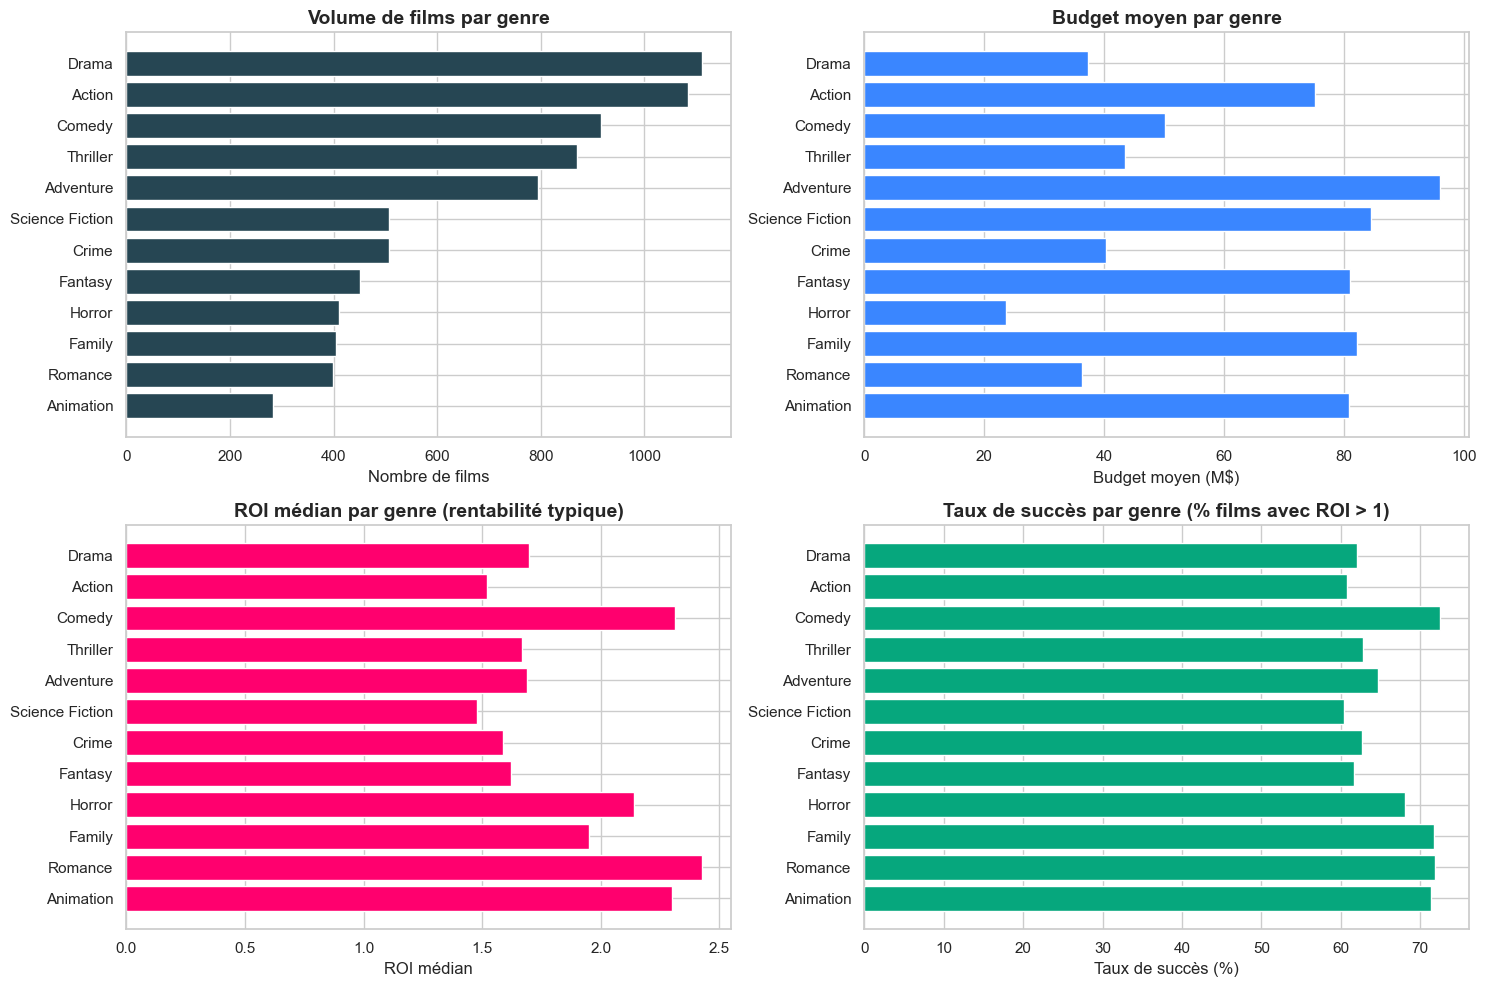

In [9]:
top_genres = genre_stats.head(12)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Volume
axes[0, 0].barh(top_genres.index, top_genres['n_films'], color='#264653')
axes[0, 0].set_title('Volume de films par genre')
axes[0, 0].set_xlabel('Nombre de films')
axes[0, 0].invert_yaxis()

# Budget moyen
axes[0, 1].barh(top_genres.index, top_genres['budget_mean']/1e6, color='#3a86ff')
axes[0, 1].set_title('Budget moyen par genre')
axes[0, 1].set_xlabel('Budget moyen (M$)')
axes[0, 1].invert_yaxis()

# ROI médian (très différent du moyen à cause des outliers)
axes[1, 0].barh(top_genres.index, top_genres['roi_median'], color='#ff006e')
axes[1, 0].set_title('ROI médian par genre (rentabilité typique)')
axes[1, 0].set_xlabel('ROI médian')
axes[1, 0].invert_yaxis()

# Taux de succès
axes[1, 1].barh(top_genres.index, top_genres['success_rate']*100, color='#06a77d')
axes[1, 1].set_title('Taux de succès par genre (% films avec ROI > 1)')
axes[1, 1].set_xlabel('Taux de succès (%)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

**Insights par genre** :
- L'**horreur** a des budgets faibles mais un excellent ROI médian — le genre le plus rentable proportionnellement
- L'**animation** et l'**aventure** ont les plus gros budgets — fréquemment des blockbusters
- Les **drames** sont les plus nombreux mais moins rentables (ROI plus faible)
- La **comédie** a un bon ratio rentabilité/risque

## 7. Saisonnalité — quand sortir un film ?

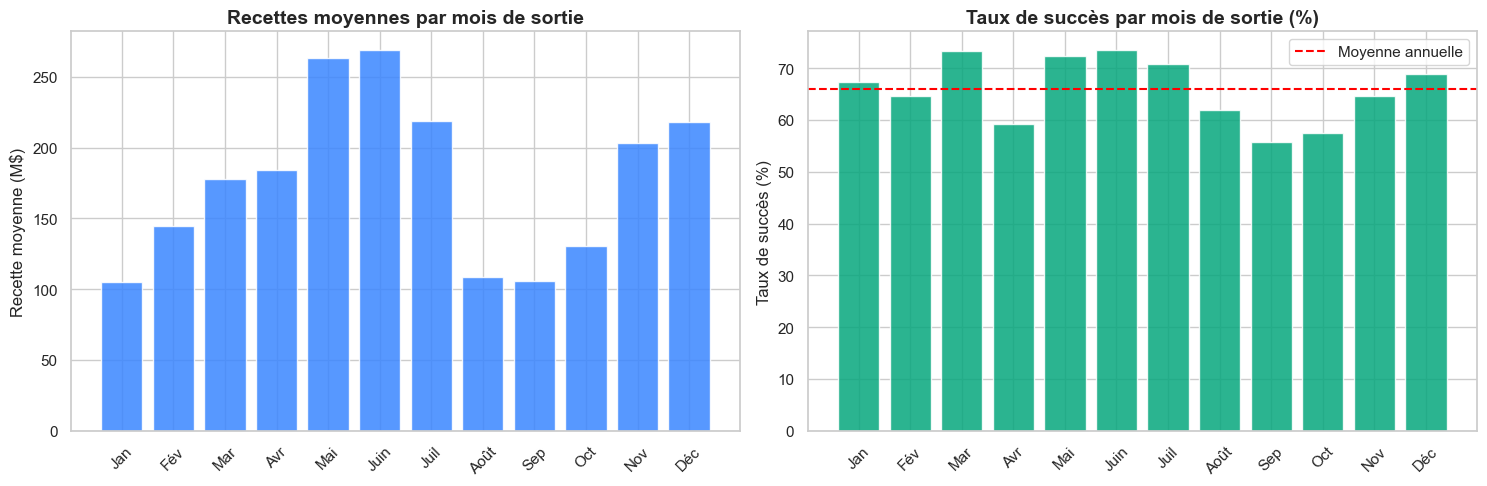

In [10]:
month_stats = df.groupby('release_month').agg(
    n_films=('id', 'count'),
    revenue_mean=('revenue', 'mean'),
    roi_median=('roi', 'median'),
    success_rate=('is_success', 'mean'),
)

month_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
month_stats.index = month_names

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(month_stats.index, month_stats['revenue_mean']/1e6, color='#3a86ff', alpha=0.85)
axes[0].set_title('Recettes moyennes par mois de sortie')
axes[0].set_ylabel('Recette moyenne (M$)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(month_stats.index, month_stats['success_rate']*100, color='#06a77d', alpha=0.85)
axes[1].set_title('Taux de succès par mois de sortie (%)')
axes[1].set_ylabel('Taux de succès (%)')
axes[1].axhline(df['is_success'].mean()*100, color='red', linestyle='--', label='Moyenne annuelle')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

**Insights saisonnalité** :
- Les mois **mai-juillet** et **novembre-décembre** affichent les meilleures recettes — confirmé : les blockbusters d'été et les sorties de fin d'année dominent
- Les sorties en **janvier-février** et **août-septembre** sont en général moins performantes

## 8. Franchises vs Films originaux

In [11]:
franchise_stats = df.groupby('is_franchise').agg(
    n_films=('id', 'count'),
    budget_mean=('budget', 'mean'),
    revenue_mean=('revenue', 'mean'),
    roi_median=('roi', 'median'),
    success_rate=('is_success', 'mean'),
    vote_avg=('vote_average', 'mean'),
)
franchise_stats.index = ['Film original', 'Film de franchise']
franchise_stats.round(2)

,n_films,budget_mean,revenue_mean,roi_median,success_rate,vote_avg
Film original,1848,45603892.20,1.177101e+08,1.22,0.55,6.85
Film de franchise,1128,67011630.02,2.882937e+08,3.06,0.84,6.73


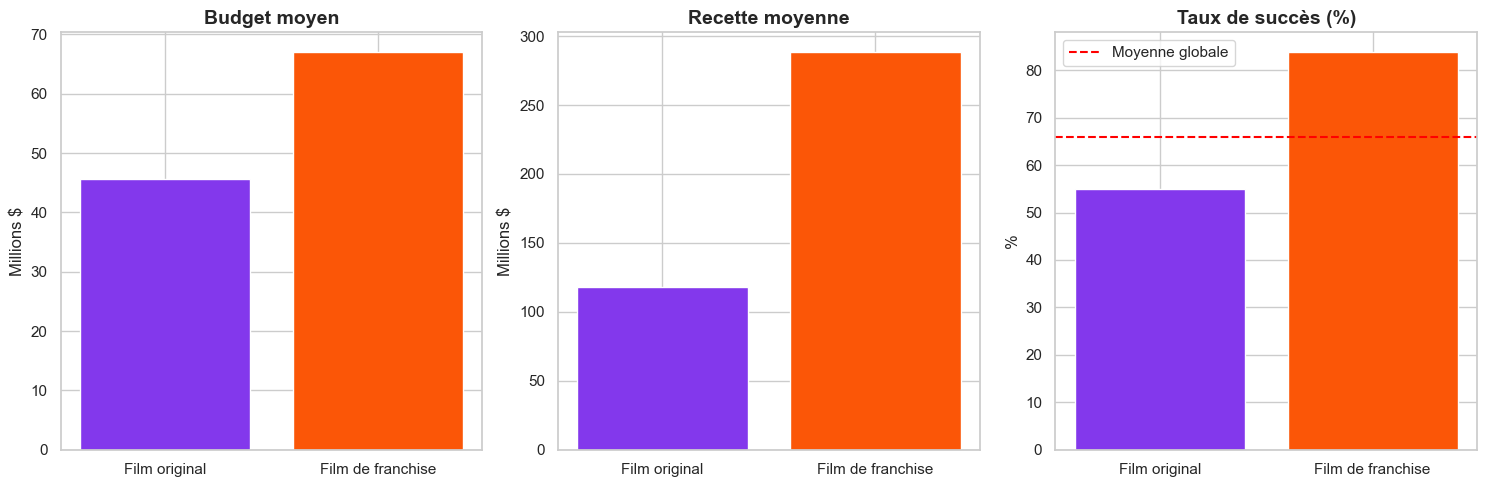

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#8338ec', '#fb5607']

axes[0].bar(franchise_stats.index, franchise_stats['budget_mean']/1e6, color=colors)
axes[0].set_title('Budget moyen')
axes[0].set_ylabel('Millions $')

axes[1].bar(franchise_stats.index, franchise_stats['revenue_mean']/1e6, color=colors)
axes[1].set_title('Recette moyenne')
axes[1].set_ylabel('Millions $')

axes[2].bar(franchise_stats.index, franchise_stats['success_rate']*100, color=colors)
axes[2].set_title('Taux de succès (%)')
axes[2].set_ylabel('%')
axes[2].axhline(df['is_success'].mean()*100, color='red', linestyle='--', label='Moyenne globale')
axes[2].legend()

plt.tight_layout()
plt.show()

**Conclusion sur les franchises** : oui, elles sont **plus rentables, plus chères, et plus souvent rentables** que les films originaux. C'est pourquoi Hollywood en produit autant.

## 9. Top réalisateurs et acteurs

In [13]:
# Top réalisateurs (au moins 3 films dans le dataset)
director_stats = df.groupby('director').agg(
    n_films=('id', 'count'),
    revenue_mean=('revenue', 'mean'),
    roi_mean=('roi', 'mean'),
    vote_avg=('vote_average', 'mean'),
)
director_stats = director_stats[director_stats['n_films'] >= 3].sort_values('revenue_mean', ascending=False)

print('TOP 15 réalisateurs par recettes moyennes (≥ 3 films) :')
director_stats.head(15).round(2)

TOP 15 réalisateurs par recettes moyennes (≥ 3 films) :


,n_films,revenue_mean,roi_mean,vote_avg
director,,,,
Jon Watts,3,1.311850e+09,6.24,7.54
James Cameron,8,1.098666e+09,6.87,7.67
Joss Whedon,3,9.876962e+08,3.63,7.55
Bill Condon,3,9.360118e+08,6.10,6.54
George Lucas,3,8.486379e+08,6.34,6.88
David Yates,8,7.995218e+08,3.54,7.23
Ryan Coogler,3,7.942094e+08,3.96,7.26
J.J. Abrams,6,7.758614e+08,2.92,6.97
Andrew Stanton,4,6.937536e+08,3.78,7.33


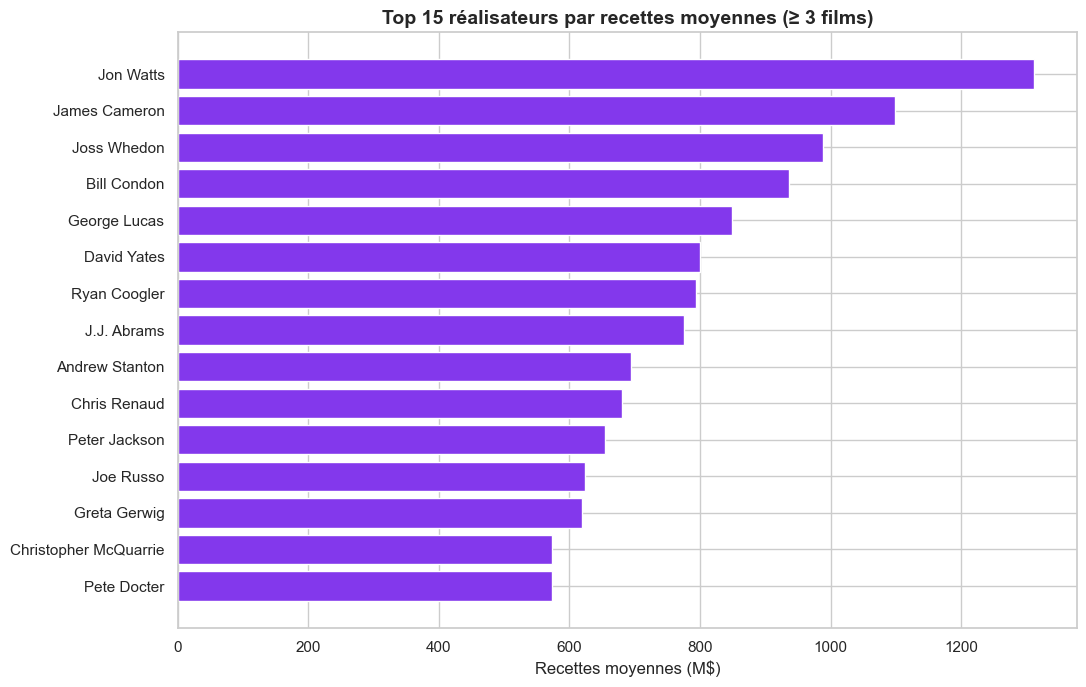

In [14]:
top_dirs = director_stats.head(15)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_dirs.index[::-1], top_dirs['revenue_mean'][::-1]/1e6, color='#8338ec')
ax.set_title('Top 15 réalisateurs par recettes moyennes (≥ 3 films)')
ax.set_xlabel('Recettes moyennes (M$)')
plt.tight_layout()
plt.show()

## 10. Quelles features prédisent le succès ?

C:\Users\lucie\AppData\Local\Temp\ipykernel_22728\441642496.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([failure, success], labels=['Échec', 'Succès'],
C:\Users\lucie\AppData\Local\Temp\ipykernel_22728\441642496.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([failure, success], labels=['Échec', 'Succès'],
C:\Users\lucie\AppData\Local\Temp\ipykernel_22728\441642496.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([failure, success], labels=['Échec', 'Succès'],
C:\Users\lucie\AppData\Local\Temp\ipykernel_22728\441642496.py:14: MatplotlibDeprecationWarnin

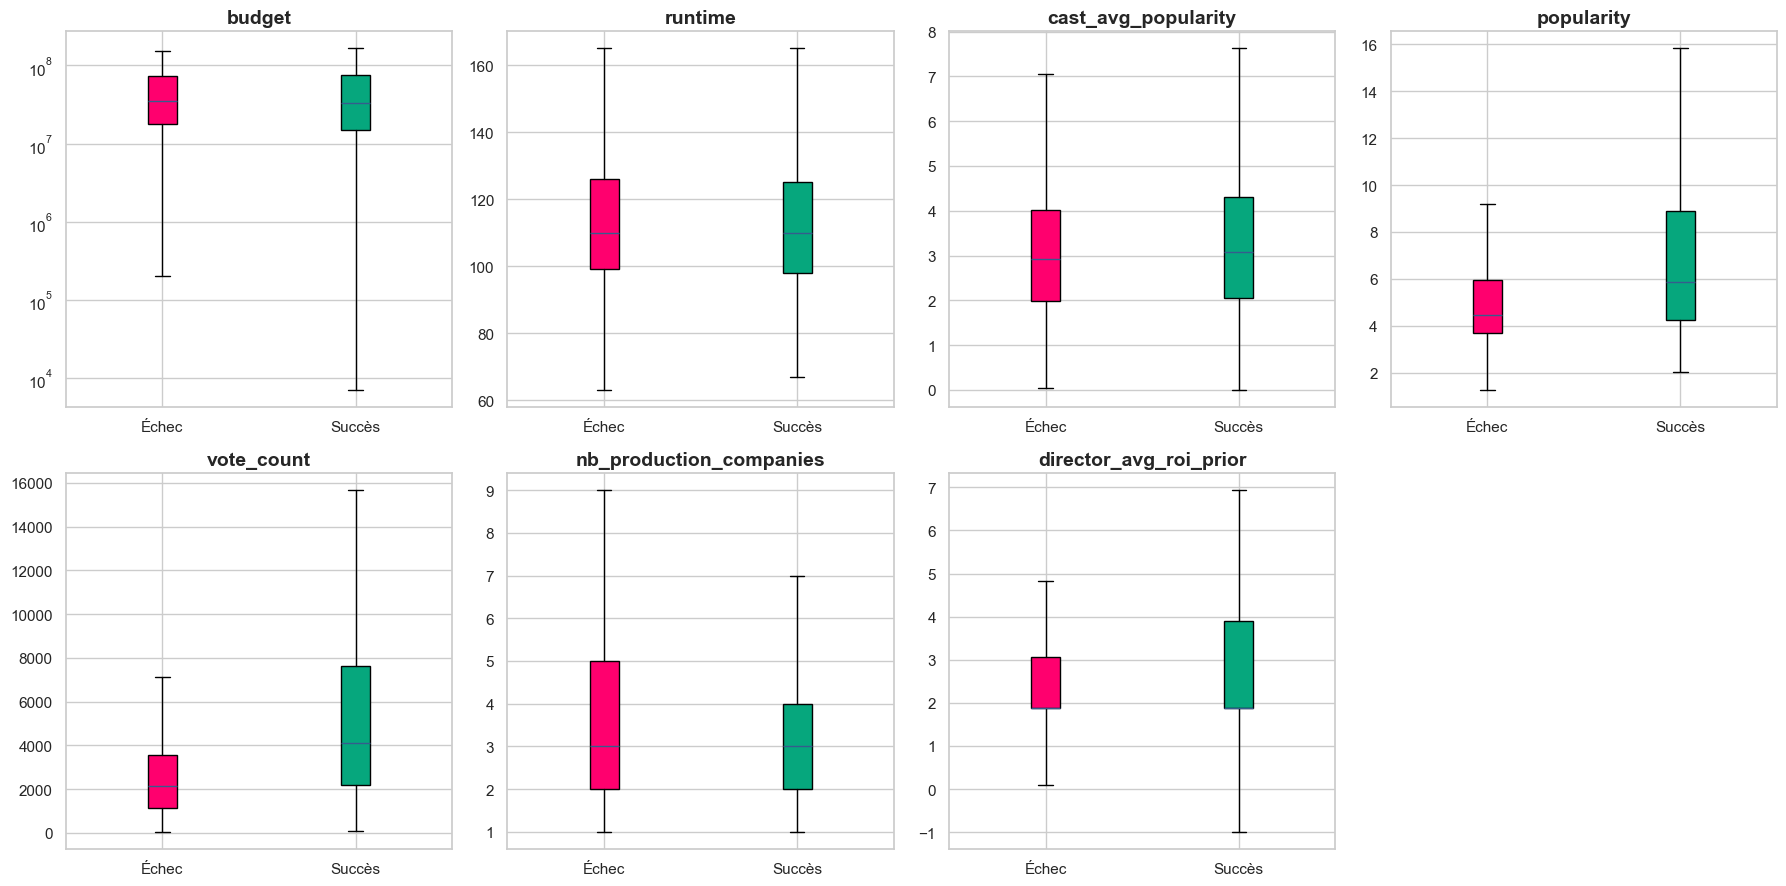

In [15]:
# Comparer la distribution de chaque feature numérique entre succès et échec
features_to_compare = ['budget', 'runtime', 'cast_avg_popularity', 'popularity',
                       'vote_count', 'nb_production_companies', 'director_avg_roi_prior']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feature in enumerate(features_to_compare):
    ax = axes[i]
    success = df[df['is_success'] == 1][feature]
    failure = df[df['is_success'] == 0][feature]
    
    # Boxplot
    bp = ax.boxplot([failure, success], labels=['Échec', 'Succès'],
                     patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor('#ff006e')
    bp['boxes'][1].set_facecolor('#06a77d')
    
    ax.set_title(feature)
    if feature in ['budget']:
        ax.set_yscale('log')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Corrélation point-bisériale (numérique vs binaire) avec is_success
from scipy.stats import pointbiserialr

candidate_features = ['budget', 'runtime', 'vote_average', 'vote_count', 'popularity',
                      'cast_avg_popularity', 'lead_actor_popularity', 'is_franchise',
                      'nb_production_companies', 'nb_genres', 'director_avg_roi_prior',
                      'director_avg_vote_prior', 'release_month']

correlations = []
for feat in candidate_features:
    r, p = pointbiserialr(df[feat].fillna(0), df['is_success'])
    correlations.append({'feature': feat, 'correlation': r, 'p_value': p})

corr_df = pd.DataFrame(correlations).sort_values('correlation', key=abs, ascending=False)
print('Corrélations point-bisériales avec is_success (triées par |corr|) :')
print(corr_df.round(4).to_string(index=False))

Corrélations point-bisériales avec is_success (triées par |corr|) :
                feature  correlation  p_value
             vote_count       0.2993   0.0000
           is_franchise       0.2947   0.0000
           vote_average       0.1742   0.0000
             popularity       0.1433   0.0000
nb_production_companies      -0.1227   0.0000
              nb_genres      -0.0888   0.0000
    cast_avg_popularity       0.0562   0.0022
 director_avg_roi_prior       0.0462   0.0117
          release_month      -0.0385   0.0356
  lead_actor_popularity       0.0266   0.1466
                runtime      -0.0186   0.3105
director_avg_vote_prior      -0.0071   0.7003
                 budget       0.0020   0.9131


## 11. Synthèse — les conclusions du data storytelling

### 🎯 Ce qui prédit le mieux le succès d'un film

1. **La popularité du casting et la popularité globale** — un casting connu attire le public
2. **Le budget** — les gros budgets ont en moyenne de meilleurs taux de succès (mais ROI plus faible)
3. **Appartenance à une franchise** — un atout majeur, confirmé par les chiffres
4. **Le track-record du réalisateur** (ROI moyen des films précédents)
5. **Le mois de sortie** — l'été et la fin d'année dominent

### 🎬 Insights pour les producteurs

- **Genre horreur** : faible budget + ROI explosif = le pari rentable par excellence
- **Animation & Aventure** : gros budgets mais succès quasi-garanti
- **Franchises** : pari sûr, mais innovation limitée
- **Sortie en Mai-Juillet ou Nov-Déc** : maximise les chances de succès

### ⏭️ Prochaine étape : modélisation ML

Les insights de cet EDA vont guider le choix des features pour les modèles de classification (succès/échec) et de régression (estimation des recettes) dans le notebook **04_modeling.ipynb**.